# Chapter 4: Classical Machine Learning

## A. Intro

Classic machine learning algorithms, especially linear models, are often the most practical choice for tabular data. They are simple, transparent, and effective. This chapter focuses on these models and introduces **Scikit-learn**, a powerful Python library for ML. 

There are many 

## B. Getting started with Scikit-learn

We will start witha an example 

1. Create synthetic data,
2. Build a pipeline with standardization and logistic regression,
3. Evaluate using cross-validation,
4. Train on all data after validation.

The goal is to teach practical applications without deep math

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

#A. generating a synthetic dataset with specified characteristics
X, y = make_classification(
    n_features=32, n_redundant=0, n_informative=24, random_state=1, n_clusters_per_class=1
)

#B. creating an instance of the LogisticRegression model
model = LogisticRegression() 

#C. creating a pipeline that sequentially applies standard scaling and the logistic regression model
pipeline = Pipeline(
    [('processing', StandardScaler()),
     ('modeling', model)]) 

#D. performing a five-fold cross-validation using the defined pipeline, calculating accuracy scores
cv_scores = cross_validate(estimator=pipeline,
                           X=X,
                           y=y,
                           scoring="accuracy",
                           cv=5)

#E. printing the mean and standard deviation of the test accuracy scores from cross-validation
mean_cv = np.mean(cv_scores['test_score'])
std_cv = np.std(cv_scores['test_score'])
print(f"accuracy: {mean_cv:0.3f} ({std_cv:0.3f})") #E

#F. fitting the logistic regression model to the entire dataset X with corresponding labels y
model.fit(X, y) 








accuracy: 0.900 (0.032)


LogisticRegression()

In [2]:
pipeline

Pipeline(steps=[('processing', StandardScaler()),
                ('modeling', LogisticRegression())])

## C. Data and EDA

### 1. Scikit-learn Pipelines 

Scikit-learn provides powerful tools to streamline and organize preprocessing and modeling steps:

* **`Pipeline`**: Chains together multiple preprocessing steps and a final estimator (e.g., model). You define a list of named steps, and it handles everything using the standard `.fit()` and `.predict()` API. It's the core tool for end-to-end tabular ML workflows.

* **`ColumnTransformer`**: Lets you apply different transformations to specific columns (e.g., scale numeric, encode categorical). It's ideal for mixed-type tabular data.

* **`FeatureUnion`**: Combines outputs of multiple transformers into a single feature space. Useful for merging different transformation strategies in parallel.

These tools help build **clean, modular, and reusable pipelines** that are easy to tune and maintain. They're essential for tackling real-world tabular data problems efficiently.

---

Below we will present an example using these tools for the Airbnb NYC datsaset


### 2. The example of a Pipeline

#### a. EDA 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# import the data
data = pd.read_csv("./data/AirBnB.csv",index_col=0)

In [5]:
#A. list of column names to be excluded from the analysis
excluding_list = ['price', 'id', 'latitude', 'longitude', 'host_id', 'last_review',
                  'name', 'host_name'] 

#B. list of names of columns that likely represent categorical variables in the dataset
categorical = ['neighbourhood_group', 'neighbourhood', 'room_type'] 

#C. list of names of columns that represent continuous numerfull exampleical variables in the dataset.
continuous = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
              'calculated_host_listings_count'] #C


In [6]:
data.shape

(48895, 16)

In [7]:
data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [8]:
# extract total summary 
summary = data.describe(include='all')[categorical+continuous].T

# add extra empty row values
summary['missing'] = data[categorical + continuous].isnull().sum()

In [9]:
summary

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,missing
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
minimum_nights,48895.0,NaN,NaN,NaN,7.029962,20.51055,1.0,1.0,3.0,5.0,1250.0,0
number_of_reviews,48895.0,NaN,NaN,NaN,23.274466,44.550582,0.0,1.0,5.0,24.0,629.0,0
reviews_per_month,38843.0,NaN,NaN,NaN,1.373221,1.680442,0.01,0.19,0.72,2.02,58.5,10052
calculated_host_listings_count,48895.0,NaN,NaN,NaN,7.143982,32.952519,1.0,1.0,1.0,2.0,327.0,0


Note: 

**neighbourhood** has high cardinality. One-hot-encoding will generate alot of columns so target enconding can be used but for now we won't use it.

In [10]:
low_card_categorical = ['neighbourhood_group', 'room_type']
high_card_categorical = ['neighbourhood']

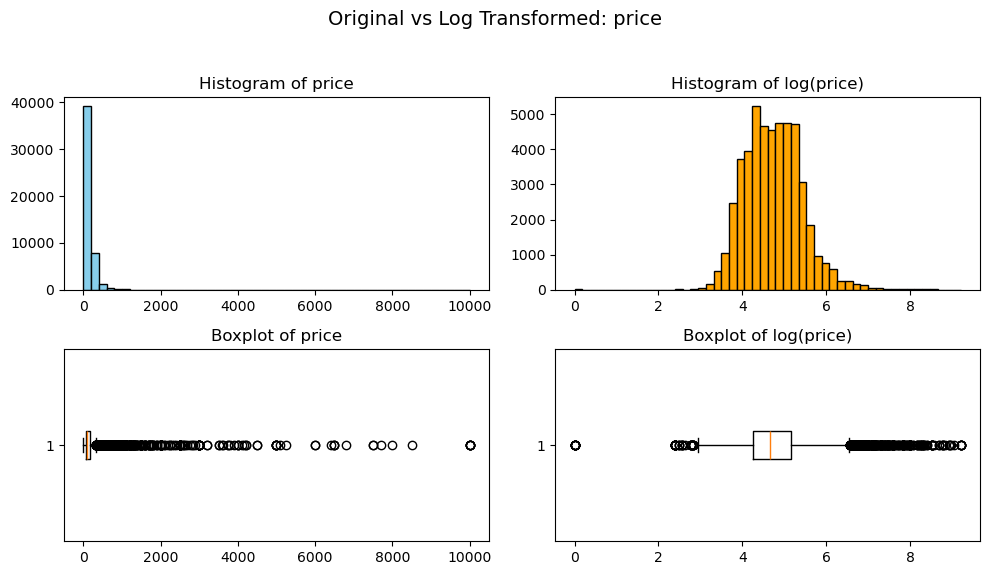

In [11]:
# Example: Replace 'your_column' with the column you want to visualize
col = 'price'
log_col = 'log_' + col

# Compute log column (add 1 to avoid log(0) if necessary)
data[log_col] = np.log1p(data[col])

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle(f'Original vs Log Transformed: {col}', fontsize=14)

# Histogram - Original
axes[0, 0].hist(data[col].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title(f'Histogram of {col}')

# Histogram - Log
axes[0, 1].hist(data[log_col].dropna(), bins=50, color='orange', edgecolor='black')
axes[0, 1].set_title(f'Histogram of log({col})')

# Boxplot - Original
axes[1, 0].boxplot(data[col].dropna(), vert=False)
axes[1, 0].set_title(f'Boxplot of {col}')

# Boxplot - Log
axes[1, 1].boxplot(data[log_col].dropna(), vert=False)
axes[1, 1].set_title(f'Boxplot of log({col})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Notice that we have a very long tail

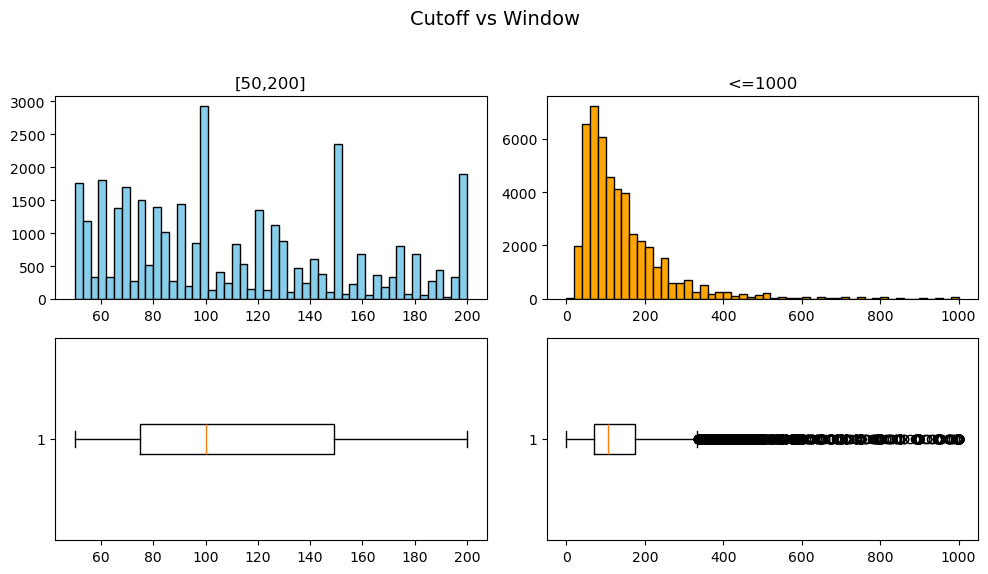

In [12]:

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle(f'Cutoff vs Window', fontsize=14)

price_capped = data.price <= 1000
price_window = (data.price >= 50) & (data.price <= 200)

axes[0, 0].hist(data.price[price_window], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title(f'[50,200]')

axes[0, 1].hist(data.price[price_capped], bins=50, color='orange', edgecolor='black')
axes[0, 1].set_title(f'<=1000')

axes[1, 0].boxplot(data.price[price_window], vert=False)

axes[1, 1].boxplot(data.price[price_capped], vert=False)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### b. Set targets for 4 different experiments

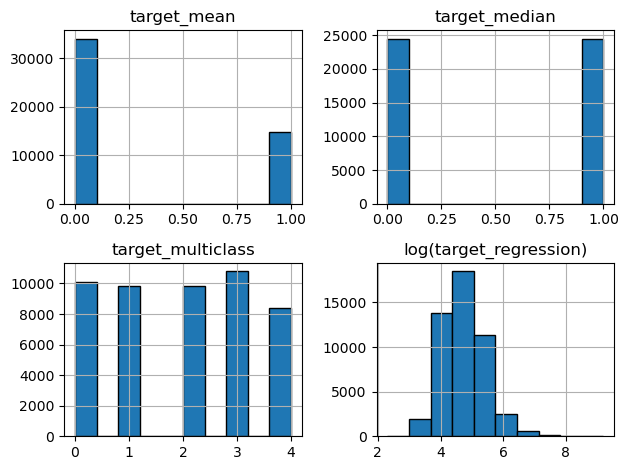

In [13]:
# Binary classifier
target_mean = (data["price"] > data["price"].mean()).astype(int)

# BInary classifier
target_median = (data["price"] > data["price"].median()).astype(int)

# Multiclass based on quantiles (q=)
target_multiclass = pd.qcut(data["price"], q=5, labels=False)

# Regression/Numerical target
target_regression = data["price"]

# everything
y = pd.DataFrame({"target_mean":target_mean,
                 "target_median":target_median,
                 "target_multiclass":target_multiclass,
                 "log(target_regression)": np.log(target_regression.replace(0,np.nan))})

y.hist(layout=(2,2),edgecolor='black')
plt.tight_layout()
plt.show()

In [14]:
target_regression.shape

(48895,)

#### c. Pipelines preparation for pre-processing

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#A. converting categorical features into one-hot encoded format
categorical_onehot_encoding = OneHotEncoder(handle_unknown='ignore')

#B. replacing missing numeric values with zero
numeric_passthrough = SimpleImputer(strategy="constant", fill_value=0)

#C. pipeline replacing missing numeric values with zero and standardizing the features
numeric_standardization = Pipeline([
       ("imputation", SimpleImputer(strategy="constant", fill_value=0)),
       ("standardizing", StandardScaler())
       ])

#D. ColumnTrabnsformer runs different processes for different sets of columns 
column_transform = ColumnTransformer(
    [('categories', categorical_onehot_encoding, low_card_categorical), #first step of the pipeline, one-hot encoding categorical features
     ('numeric', numeric_passthrough, continuous), #second step of the pipeline, handling numeric features
    ],
    remainder='drop', #the features not processed by the pipeline are dropped from the result
    verbose_feature_names_out=False, # names of the features are kept as they originally are
    sparse_threshold=0.0 # he result is always a dense matrix, i.e., a NumPy array
)


In [16]:
column_transform

ColumnTransformer(sparse_threshold=0.0,
                  transformers=[('categories',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['neighbourhood_group', 'room_type']),
                                ('numeric',
                                 SimpleImputer(fill_value=0,
                                               strategy='constant'),
                                 ['minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count'])],
                  verbose_feature_names_out=False)

In [17]:
X = column_transform.fit_transform(data)
print(type(X), X.dtype, X.shape)

<class 'numpy.ndarray'> float64 (48895, 12)


## D. Classical ML techniques

### 1. Introduction

##### Model Evaluation with Classical Machine Learning

We'll apply classic ML models to tabular data using the Airbnb NYC dataset. Each model will be introduced with a short explanation and a working code example.

To ensure reproducibility and fair comparison, we follow these best practices:

* ✅ Use pipelines that include both preprocessing and the model
* 📏 Evaluate performance using RMSE (for regression) or accuracy (for classification)
* 📊 Report mean and standard deviation of cross-validation scores

---

##### Evaluation Strategy: Cross-Validation

* **Cross-validation** estimates how well a model will generalize to new data.
* We use **k-fold CV** (usually `k=5` or `k=10`) to measure out-of-sample performance.
* Performance is averaged across folds to get a reliable estimate, along with standard deviation for uncertainty.

⚠️ Cross-validation assumes your data distribution stays stable over time. Real-world changes (a.k.a. **concept drift**) may reduce future model performance.




### 2. Linear Regression

* Predicts a numeric target using a **weighted sum of features**.
* Requires **numeric inputs** (including one-hot encoded categoricals).
* Learns **coefficients** to minimize prediction error.
* Easy to **interpret** via feature weights.
* Watch out for: ❌ Missing values, ❗ Outliers, 🔁 Correlated features (multicollinearity)
* Fast, simple, and great as a **baseline model**.
* Works well in **pipelines** with preprocessing and cross-validation.


##### Standard version

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

#A. ColumnTransformer, transforming data into numeric features and imputing missing data
column_transform = ColumnTransformer(
    [('categories', categorical_onehot_encoding, low_card_categorical),
     ('numeric', numeric_passthrough, continuous)],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=0.0)

#B. vanilla  linear regression model
model = LinearRegression() 

#C. pipeline assembling ColumnTransformer and model
model_pipeline = Pipeline(
    [('processing', column_transform),
     ('modeling', model)] 
)

#D. cross-validation strategy based on five folds and random sampling
cv = KFold(5, shuffle=True, random_state=0)

#E. function for evaluation metric derived from mean squared error
rmse =  make_scorer(mean_squared_error, squared=False)

#F. automated cross-validate procedure
cv_scores = cross_validate(estimator=model_pipeline,
                           X=data[price_window],
                           y=target_regression[price_window],
                           scoring=rmse,
                           cv=cv,
                           return_train_score=True,
                           return_estimator=True) 

#G. reporting the results in terms of evaluation metric, standard deviation, fitting, and prediction time
mean_cv = np.mean(cv_scores['test_score'])
std_cv = np.std(cv_scores['test_score'])
fit_time = np.mean(cv_scores['fit_time'])
score_time = np.mean(cv_scores['score_time'])

print(f"""mean_csv = {mean_cv:0.3f} ({std_cv:0.3f})
fit_time: {fit_time:0.2f} secs 
pred_time: {score_time:0.2f} secs""")

mean_csv = 34.120 (0.300)
fit_time: 0.03 secs 
pred_time: 0.01 secs


##### Feature engineered

In [19]:

#A creating  an empty DataFrame
data_2 = data[[]].copy()

#B a binary column indicating whether the 'neighbourhood_group' is 'Manhattan'.
data_2['neighbourhood_group_Manhattan'] = ((data['neighbourhood_group']=='Manhattan').astype(int)) 

#C binary column indicating whether the 'neighbourhood_group' is 'Queens'
data_2['neighbourhood_group_Queens'] = ((data['neighbourhood_group']=='Queens').astype(int)) 

#D binary column to indicating whether the 'room_type' is 'Entire home/apt'
data_2['room_type_Entire home/apt'] = ((data['room_type']=='Entire home/apt').astype(int))

#E a column containing the natural logarithm of the values in the 'minimum_nights' column plus 1
data_2['minimum_nights_log'] = np.log1p(data["minimum_nights"]) 

#F a column containing the natural logarithm of the values in the 'number_of_reviews' column plus 1
data_2['number_of_reviews_log'] = np.log1p(data["number_of_reviews"])

#G a product of the binary 'neighbourhood_group_Manhattan' and 'room_type_Entire home/apt' columns
data_2['neighbourhood_group_Manhattan*room_type_Entire home/apt'] = (data_2['neighbourhood_group_Manhattan'] * data_2['room_type_Entire home/apt']) #G

#H a product of 'availability_365' and the binary 'neighbourhood_group_Manhattan' column
data_2['availability_365*neighbourhood_group_Manhattan'] = (data['availability_365'] * data_2['neighbourhood_group_Manhattan']) #H

#I a product of 'availability_365' and the binary 'room_type_Entire home/apt' column
data_2['availability_365*room_type_Entire home/apt'] = (data['availability_365'] * data_2['room_type_Entire home/apt']) #I


rmse = make_scorer(mean_squared_error, squared=False)
cv = KFold(5, shuffle=True, random_state=0)
cv_scores = cross_validate(estimator=LinearRegression(),
                           X=data_2[price_window],
                           y=target_regression[price_window],
                           scoring=rmse,
                           cv=cv,
                           return_train_score=True,
                           return_estimator=True)

mean_cv = np.mean(cv_scores['test_score'])
std_cv = np.std(cv_scores['test_score'])

print(f"""mean_csv = {mean_cv:0.3f} ({std_cv:0.3f})
fit_time: {fit_time:0.2f} secs 
pred_time: {score_time:0.2f} secs""")












mean_csv = 33.937 (0.240)
fit_time: 0.03 secs 
pred_time: 0.01 secs


### 3. Regularized methods

* **Linear regression** is simple and interpretable, but it has **high bias** and struggles to model complex relationships.
* **Adding features** (e.g. squares, logs, interactions) reduces bias but increases **variance** and **risk of overfitting**

* **Regularization** controls model complexity by penalizing large coefficients:
  * **L1 (Lasso)**: pushes some coefficients to **zero**, effectively doing **feature selection**.
  * **L2 (Ridge)**: shrinks coefficients **closer to zero**, especially useful with **multicollinearity**.<br></br>
    
* Both regularization methods improve **generalization** by discouraging the model from memorizing noise.
* **Polynomial feature expansion** (e.g. using `PolynomialFeatures` in scikit-learn) introduces interactions and powers of features, helping model non-linear relationships.
* However, this expansion leads to **many features**, making regularization essential to avoid overfitting.

* In practice:

  * Use **L1** when you want a **sparse model** (i.e., automatic feature selection).
  * Use **L2** when you have many correlated features and want to **stabilize** their influence.


In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso

#### a. L2 ridge regression

In [21]:
# Set up preprocessing
column_transform = ColumnTransformer(
    [('categories', categorical_onehot_encoding, low_card_categorical),
     ('numeric', numeric_passthrough, continuous)],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=0.0)

#A. PolynomialFeatures instance performing second-degree polynomial expansion on the features
polynomial_expansion = PolynomialFeatures(degree=2)

#B. a Ridge regression model instance with a regularization strength (alpha) of 2500
model = Ridge(alpha=2500.0) 

#C. pipeline for column transformation, polynomial expansion, standardization, and Ridge regression modeling
model_pipeline = Pipeline(
    [('processing', column_transform),
     ('polynomial_expansion', polynomial_expansion),
     ('standardizing', numeric_standardization),
     ('modeling', model)]
) 

#D five-fold cross-validation using the defined pipeline and calculating RMSE scores
cv = KFold(5, shuffle=True, random_state=0)
rmse =  make_scorer(mean_squared_error, squared=False)
cv_scores = cross_validate(estimator=model_pipeline,
                           X=data[price_window],
                           y=target_regression[price_window],
                           scoring=rmse,
                           cv=cv,
                           return_train_score=True,
                           return_estimator=True)

#E. printing the mean and standard deviation of the test RMSE scores from cross-validation
mean_cv = np.mean(cv_scores['test_score'])
std_cv = np.std(cv_scores['test_score'])
fit_time = np.mean(cv_scores['fit_time'])
score_time = np.mean(cv_scores['score_time'])


print(f"""mean_csv = {mean_cv:0.3f} ({std_cv:0.3f})
fit_time: {fit_time:0.2f} secs 
pred_time: {score_time:0.2f} secs""")


mean_csv = 33.936 (0.288)
fit_time: 0.11 secs 
pred_time: 0.01 secs


#### b. L1 Lasso

In [22]:
#A. a Lasso regression model instance with a regularization strength (alpha) of 0.1
model = Lasso(alpha=0.1)

#B. pipeline applying column transformation, polynomial expansion, standardization, and Lasso regression modeling
model_pipeline = Pipeline(
    [('processing', column_transform),
     ('polynomial_expansion', polynomial_expansion),
     ('standardizing', numeric_standardization),
     ('modeling', model)]
) 

#C. five-fold cross-validation using the defined pipeline and calculating RMSE scores
cv = KFold(5, shuffle=True, random_state=0)
rmse =  make_scorer(mean_squared_error, squared=False)

cv_scores = cross_validate(estimator=model_pipeline,
                           X=data[price_window],
                           y=target_regression[price_window],
                           scoring=rmse,
                           cv=cv,
                           return_train_score=True,
                           return_estimator=True)

#D. printing the mean and standard deviation of the test RMSE scores from cross-validation
mean_cv = np.mean(cv_scores['test_score'])
std_cv = np.std(cv_scores['test_score'])
fit_time = np.mean(cv_scores['fit_time'])
score_time = np.mean(cv_scores['score_time'])

print(f"""mean_csv = {mean_cv:0.3f} ({std_cv:0.3f})
fit_time: {fit_time:0.2f} secs 
pred_time: {score_time:0.2f} secs""")


mean_csv = 33.913 (0.283)
fit_time: 0.47 secs 
pred_time: 0.01 secs


In [23]:
# preprocessing
model_preprocess = Pipeline(
    [('processing', column_transform),
     ('polynomial_expansion', polynomial_expansion),
     ('standardizing', numeric_standardization)]) 

model_preprocess.fit_transform(data[price_window]).shape

(35484, 91)

In [24]:
# number of estimator which have weights not zero
(cv_scores['estimator'][0]['modeling'].coef_.round(5) !=0).sum()

47

Where we can see that the number of estimators has been halved

### 4. Logistic Regression

#### 🚀 Intro
Logistic regression extends linear regression to handle **binary classification** by predicting **probabilities** instead of continuous values. It uses the **logit function** as the **link function**, which maps probabilities to the real number line, allowing the use of a linear model. The model output is then passed through the **inverse of the logit**, the **sigmoid function**, to convert it back into a probability between 0 and 1. This approach enables the model to estimate the likelihood that a sample belongs to the **positive class**, making logistic regression a powerful and intuitive tool for classification tasks.


In **logistic regression**, the **link function** plays a crucial role in connecting the linear model to the probability output.

* 🔗 **Link Function**:
  The link function is the **logit function**, defined as:

  $$
  \text{logit}(p) = \log\left(\frac{p}{1 - p}\right)
  $$

  It transforms a **probability $p \in (0,1)$** into a value on the **real number line** $(-\infty, \infty)$.

* 🔁 **Inverse of the Link Function**:
  The inverse of the logit function is the **sigmoid function** (also called the logistic function), which is used to **map the linear model output back to a probability**:

  $$
  \text{sigmoid}(z) = \frac{1}{1 + e^{-z}}
  $$

So in logistic regression:

1. The model computes a **linear combination** of features:

   $$
   z = X\beta + b
   $$
2. This output $z$ is passed through the **inverse of the link function** (i.e., the **sigmoid**) to produce a probability:

   $$
   p = \frac{1}{1 + e^{-z}}
   $$

🔍 **Key Clarification**:
The **logit** is the link function.
The **sigmoid** is its inverse, used to produce probabilities from the linear model.



#### 🍦 Vanilla code

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score

accuracy = make_scorer(accuracy_score)
cv = KFold(5, shuffle=True, random_state=0)

#A.  logistic regression model instance with the "saga" solver, no penalty, and a maximum of 1,000 iterations
model = LogisticRegression(solver="saga", penalty=None, max_iter=1_000) 

#B. a column transformer applying one-hot encoding to categorical features and standardization to numeric features
column_transform = ColumnTransformer(
    [('categories', categorical_onehot_encoding, low_card_categorical),
     ('numeric', numeric_standardization, continuous)],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=0.0)

#C. a pipeline that sequentially applies column transformation and logistic regression modeling
model_pipeline = Pipeline(
    [('processing', column_transform),
     ('modeling', model)])

#D. five-fold cross-validation using the defined pipeline and calculating accuracy scores
cv_scores = cross_validate(estimator=model_pipeline,
                           X=data,
                           y=target_median,
                           scoring=accuracy,
                           cv=cv,
                           return_train_score=True,
                           return_estimator=True) #D

#E. printing the mean and standard deviation of the test accuracy scores from cross-validation
mean_cv = np.mean(cv_scores['test_score'])
std_cv = np.std(cv_scores['test_score'])
fit_time = np.mean(cv_scores['fit_time'])
score_time = np.mean(cv_scores['score_time'])

print(f"""mean_csv = {mean_cv:0.3f} ({std_cv:0.3f})
fit_time: {fit_time:0.2f} secs 
pred_time: {score_time:0.2f} secs""")






mean_csv = 0.820 (0.005)
fit_time: 1.30 secs 
pred_time: 0.01 secs


#### 🧠 Explanation

When using **logistic regression**, the **feature preprocessing steps remain the same** as in linear regression (e.g., scaling, encoding), but the algorithm introduces **classification-specific parameters** that give you greater flexibility and control.



#### ⚙️ Key Parameters in Logistic Regression

1. **Penalty**
   You can directly set a **regularization penalty** to control overfitting:

   * `L1`: encourages sparsity (some coefficients become zero).
   * `L2`: penalizes large coefficients (shrinks them).
   * `elasticnet`: a mix of L1 and L2.

2. **Solver**
   The **solver** determines the optimization algorithm used to train the model. Each solver supports different penalties and is suited for different kinds of datasets:

   | Solver            | Supports Penalties       | Best Use Case                                                                      |
   | ----------------- | ------------------------ | ---------------------------------------------------------------------------------- |
   | `lbfgs`           | L2, none                 | General use, efficient for medium-sized data                                       |
   | `liblinear`       | L1, L2                   | Good for **small datasets**, supports **one-vs-rest** only                         |
   | `newton-cg`       | L2, none                 | Handles multiclass, better for **larger datasets**                                 |
   | `newton-cholesky` | L2, none                 | Faster than newton-cg for well-conditioned data                                    |
   | `sag`             | L2, none                 | Good for **large datasets**, but needs standardized features                       |
   | `saga`            | L1, L2, elasticnet, none | Handles **large datasets**, supports all penalties, requires standardized features |

> ⚠️ Note: Some solvers (like `sag` and `saga`) **require feature scaling** to perform efficiently.

---



#### 🎯 Multiclass Classification

Great question! Let's break down the **mathematical difference** between **One-vs-Rest (OvR)** and **Multinomial** logistic regression in **multiclass classification**.



| Feature          | One-vs-Rest (OvR)                | Multinomial (Softmax)                  |
| ---------------- | -------------------------------- | -------------------------------------- |
| Number of models | K binary classifiers             | One multiclass model                   |
| Probability sum  | Not guaranteed to sum to 1       | Guaranteed to sum to 1                 |
| Optimization     | Each class trained independently | All classes trained jointly            |
| Expression       | Sigmoid applied to each class    | Softmax over all class scores          |
| Use case         | Simpler, small data              | Better when class relationships matter |




Logistic regression keeps feature preprocessing similar to linear regression but adds flexibility via **penalty** and **solver** parameters. You can choose from several optimization algorithms (`lbfgs`, `liblinear`, `saga`, etc.) based on dataset size, penalty type, and performance needs. For **multiclass classification**, logistic regression supports both **one-vs-rest (OvR)** and **multinomial** strategies. OvR builds a binary model per class, while multinomial uses a single model to predict all classes together—ideal when inter-class relationships are important.


#### 💻 Regularized Logistic regression

In [26]:
# Listing 4.8 L2 regularized multiclass linear regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score

accuracy = make_scorer(accuracy_score)
cv = KFold(5, shuffle=True, random_state=0)

#A. logistic regression model instance with L2 penalty, regularization C=0.1, "sag" solver, "ovr" multi-class strategy
model = LogisticRegression(penalty="l2", C=0.1, solver="sag", multi_class="ovr", max_iter=1000)

#B. column transformer that applies one-hot encoding to categorical features and standardization to numeric features
column_transform = ColumnTransformer(
    [('categories', categorical_onehot_encoding, low_card_categorical),
     ('numeric', numeric_standardization, continuous)],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=0.0)

#C. pipeline that sequentially applies column transformation and logistic regression modeling
model_pipeline = Pipeline(
    [('processing', column_transform),
     ('modeling', model)])

#D. cross-validation using the defined pipeline and calculating accuracy scores
cv_scores = cross_validate(estimator=model_pipeline,
                           X=data,
                           y=target_multiclass,
                           scoring=accuracy,
                           cv=cv,
                           return_train_score=True,
                           return_estimator=True) #D

0.425 (0.002) fit: 14.73 secs pred: 0.01 secs


In [28]:
#E. printing the mean and standard deviation of the test accuracy scores from cross-validation
mean_cv = np.mean(cv_scores['test_score'])
std_cv = np.std(cv_scores['test_score'])
fit_time = np.mean(cv_scores['fit_time'])
score_time = np.mean(cv_scores['score_time'])

print(f"""mean_csv = {mean_cv:0.3f} ({std_cv:0.3f})
fit_time: {fit_time:0.2f} secs 
pred_time: {score_time:0.2f} secs""")


mean_csv = 0.425 (0.002)
fit_time: 14.73 secs 
pred_time: 0.01 secs


### 5. Generalized linear methods

#### 🚀 Intro

The concept of extending **logistic regression** to other types of data via **logit transformations** can go beyond binary classification and **Bernoulli distributions**. It applies to a wide range of target variables, especially in fields like **finance**, **insurance**, or **climate modeling**, where target data may be **counts**, **positively skewed continuous values**, or **totals**.

To model such data effectively, we use **Generalized Linear Models (GLMs)** tailored to specific distributions:

* **Poisson distribution**: Used for count data (e.g., number of claims, rain events).
* **Gamma distribution**: Used for skewed positive data (e.g., cost per claim, rainfall amount).
* **Tweedie distribution**: A hybrid of Poisson and Gamma, used for modeling totals (e.g., total cost or total rainfall).
* **Inverse Gaussian**: For continuous, positively skewed data.

The **Scikit-learn `TweedieRegressor`** allows flexible modeling of various distributions via the **power parameter**:

* `0`: Normal
* `1`: Poisson
* `1 < p < 2`: Compound Poisson-Gamma (Tweedie)
* `2`: Gamma
* `3`: Inverse Gaussian

When using these models, be aware of **distribution limitations**:

* Poisson, Gamma, Tweedie, and Inverse Gaussian require **positive non-zero targets**.
* If data contains **zeros or negatives**, it must be adjusted (e.g., by adding an offset).

Using the **right distribution** improves performance, especially when dealing with **non-normal or heavy-tailed data**, such as **Airbnb price prediction**.


#### 💻 Code samples

In [36]:
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

#A a list of experiments, made of a distribution name, power parameter and minimum target value
experiments = [
    ['normal', 0, float('-inf')],
    ['poisson', 1, 0.0],
    ['tweedie', 1.5, 0.1],
    ['gamma', 2, 0.1],
    ['inverse gaussian', 3, 0.1]] #A

In [50]:
results = {j[0]:[] for j in experiments}

#B. looping through the experiments list with distribution names and power parameters
for experiment, power, min_val in experiments:

    column_transform = ColumnTransformer(
        [('categories', categorical_onehot_encoding, low_card_categorical),
         ('numeric', numeric_standardization, continuous)],
        remainder='drop',
        verbose_feature_names_out=False,
        sparse_threshold=0.0)

    #C. instance of the TweedieRegressor model with the specified power parameter for the current experiment
    model = TweedieRegressor(power=power, max_iter=1000)

    model_pipeline = Pipeline(
        [('processing', column_transform),
         ('modeling', model)])

    cv = KFold(5, shuffle=True, random_state=0)
    rmse =  make_scorer(mean_squared_error, squared=False)

    #D. clipping the target regression data to a minimum value, accordingly to the used distribution
    cv_scores = cross_validate(estimator=model_pipeline,
                               X=data,
                               y=target_regression.clip(lower=min_val), #D
                               scoring=rmse,
                               cv=cv,
                               return_train_score=True,
                               return_estimator=True)

    mean_cv = np.mean(cv_scores['test_score'])
    std_cv = np.std(cv_scores['test_score'])
    fit_time = np.mean(cv_scores['fit_time'])
    score_time = np.mean(cv_scores['score_time'])

    #E. printing the experiment name along with the results from cross-validation
    results[experiment].append(mean_cv)
    results[experiment].append(std_cv)
    results[experiment].append(fit_time)
    results[experiment].append(score_time)


results = pd.DataFrame(results,index=['mean','std','train_time','test_time'])
results.T



,mean,std,train_time,test_time
normal,233.857702,15.826430,0.031055,0.006146
poisson,229.188705,16.075231,0.047144,0.005906
tweedie,229.607485,16.047049,0.034380,0.006016
gamma,233.991103,15.828200,0.028210,0.006053
inverse gaussian,239.576668,15.453261,0.024797,0.005979


### 6. Batch learning: Handling large datasets with stochastic gradient descent

When your dataset is too big to fit into memory (RAM), you can't use regular machine learning methods easily. One solution (besides deep learning) is **out-of-core learning**.




#### 🔄 What is Out-of-Core Learning?

* You **don’t load all the data at once**.
* Instead, the model learns **in small chunks**, called **batches**, directly from storage (like a database or cloud).
* This works because:

  * Modern storage systems let you fetch specific data slices efficiently.
  * Some tools (e.g., **Apache Kafka**, **Amazon Kinesis**) stream data to your model in real-time.

---

#### 💡 Why It Works

* Models like **linear or logistic regression** are easy to update incrementally.
* You start by estimating model coefficients using a small batch.
* Then, you **update those estimates** as you process more batches.
* In the end, the result is nearly as good as if you trained on the full dataset all at once.

---

#### ⚠️ Key Considerations

* You may need to **repeat batches** to improve learning, but repeating too much can cause **overfitting**.
* **Regularization** (like L1 or L2) helps reduce overfitting.
* **Cross-validation is hard** with streamed data because you usually see each data point once and discard it.

  * Instead, use a separate test set or reserve every *n-th batch* for testing.

---

#### ✅ Bottom Line

Out-of-core learning lets you train models on datasets that are **too big for memory**, by processing data **bit by bit**. It's slower and requires care to avoid overfitting, but it’s effective and scalable.


#### 💻 Code samples

In [51]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import gen_batches
from sklearn.metrics import accuracy_score

#A. defining a function to generate batches of data for training
def generate_batches(X, y, batch_size, random_state):
    """split dataset into batches """
    
    #B. generating batches of data indices for processing
    examples = len(X)
    batches = gen_batches(n=examples, batch_size=batch_size)
    sequence = np.arange(examples)

    #C. shuffling the sequence of examples if a random state is provided
    if random_state:
      np.random.seed(random_state)
      np.random.shuffle(sequence)

    #D. yielding batches of input features and corresponding labels
    for batch in batches:
        items = sequence[batch]
        yield(X.iloc[items], y.iloc[items])

#E. creating an instance of the SGDClassifier model with logistic loss, averaging, L2 penalty, and alpha regularization
model = SGDClassifier(loss="log_loss",
                      average=True,
                      penalty='l2',
                      alpha=0.001)

column_transform = ColumnTransformer(
    [('categories', categorical_onehot_encoding, low_card_categorical),
     ('numeric', numeric_standardization, continuous)],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=0.0)

#F. splitting the data and target into training and testing sets using a 80-20 ratio
X_train, X_test, y_train, y_test = train_test_split(data, target_median,
                                                    test_size=0.20, random_state=0)

#G. iterating through training data batches, fitting the column transformer on the first batch.
iterations = 10
for j in range(iterations): 
    generator = generate_batches(X_train, y_train, batch_size=256, random_state=j)
    for k, (Xt, yt) in enumerate(generator):
        if k == 0:
            column_transform.fit(Xt)

        Xt = column_transform.transform(Xt)

        #H. using partial fitting to train the model on the first batch, specifying the classes
        if k == 0:
            model.partial_fit(Xt, yt, classes=(0, 1))
        
        #I. using partial fitting to further train the model on subsequent batches
        else:
            model.partial_fit(Xt, yt)

predictions = model.predict(column_transform.transform(X_test))
score = accuracy_score(y_true=y_test, y_pred=predictions)
print(f"Accuracy on test set: {score:0.3f}") #J printing accuracy score of test data predictions

Accuracy on test set: 0.818


#### 🧠 Key Points & Tips for Using SGD Effectively

a. **Use Batches**:
   Split large datasets into mini-batches for efficiency and memory handling.

b. **Learning Rate Matters**:

   * Too high → overshooting, divergence
   * Too low → slow convergence
     🔧 **Tune the learning rate carefully**<br></br>

c. **Randomize Data Order**:
   Shuffle data before each epoch to avoid biased updates and improve generalization.

d. **Feature Scaling is Crucial**:
   Normalize/standardize features — SGD is sensitive to feature scales.

e. **Out-of-Core Learning**:
   Useful for large datasets that don’t fit in memory — linear/logistic models can be trained incrementally using `partial_fit()`.

f. **Avoid Overfitting**:
   * Don’t repeat the same data too often
   * Use techniques like **early stopping** to halt training when improvement stalls<br></br>

g. **Weight Updates**:
   Use **averaging** of coefficients instead of direct replacement to smooth out noisy updates (especially helpful with outliers).

h. **Watch for Complex Landscapes**:
   In deep models, SGD may get stuck in **local minima or plateaus** — use advanced optimizers or techniques (e.g., momentum, Adam) if needed.


 ### 7. Choosing the best algorthm


#### 📏 Rows (Number of Samples):

* **≤ 100 rows** → Use **rule-based or statistical methods** (too little data for ML).
* **100 – 1,000 rows** → Use **linear models** (e.g., linear/logistic regression) to avoid overfitting.
* **1,000 – 100,000 rows** → No clear winner. **Experiment** with various algorithms.
  * Deep learning may work **only if** there's structure (e.g., time series, hierarchies).<br></br>
    
* **Up to 1 billion rows (10⁹)** → **Gradient boosting** (e.g., XGBoost, LightGBM) often best.
* **> 1 billion rows** → Use **deep learning** or **out-of-core/online learning**, which handle large-scale data efficiently.

#### 📐 Columns (Number & Type of Features):

* **Sparse data** (many binary or zero-heavy features) → Consider **online learning** or **deep learning** sooner, as they handle high-dimensional sparsity better.

#### 🧠 Final Tips

* There’s **no single best algorithm** — always **test and compare**.
* Algorithm choice depends not just on data size, but also on:
  * 💾 Memory/compute limits
  * ⚙️ Model interpretability/control
  * 🎯 Problem-specific structure <br></br>
    
* Be flexible: **“No Free Lunch” theorem** implies performance varies by task.



## E. Summary


### Choosing a Machine Learning Algorithm

Determining what machine learning algorithm to use involves several factors: the number of examples and features, the expected performances, speed at prediction time, and interpretability. As a general rule of thumb:

- **Statistical machine learning** is suitable for datasets with few cases.  
- **Classical machine learning** is suitable for datasets with a moderate number of cases.  
- **Gradient boosting algorithms** are particularly effective for datasets with a moderate to large number of cases.  
- **Deep learning** solutions are the most feasible and effective for datasets with massive amounts of data.

### Scikit-learn Overview

Scikit-learn is an open-source library for machine learning that offers a wide range of models for classification and regression, as well as functions for clustering, dimensionality reduction, preprocessing, and model selection. Its core advantages include:

- Consistent API across models  
- Supports in-memory and out-of-core learning  
- Supports working with pandas DataFrames  
- Ideal for tabular problems  
- Easy to install  
- Extensive documentation

### Linear Regression

Linear regression is the summation of weighted features that have been converted to numeric values (e.g., one-hot encoding for categorical features):

- The algorithm finds optimal weight values (coefficients) to minimize the residual sum of squares between targets and predictions.  
- It is easy to explain and understand how each feature contributes to the final result.  
- A high correlation between features (multicollinearity) can cause conceptual misunderstanding.  
- Linear regression is computationally simple and easy to implement.  
- It is limited in its ability to fit complex problems with nonlinear data unless features are carefully engineered (e.g., creating polynomial features to capture nonlinear relationships).

### Regularization

Regularization is used to prevent overfitting by reducing the complexity of a regression model and improving its generalization performance. There are two main types:

- **L1 regularization (Lasso regression)**: pushes many coefficients to zero, effectively removing some features from the model.  
- **L2 regularization**: generally reduces the size of coefficients.  

**Key points:**

- L1 is helpful for feature selection.  
- L2 reduces overfitting when using many features and is faster to compute.

### Logistic Regression

Linear regression can be extended to classification problems using:

- The **logit function** to transform the target  
- The **Bernoulli conditional distribution** to optimize the algorithm  

This results in a **logistic regression model** suitable for:

- Binary classification  
- Multiclass classification  
- Multilabel classification  

Logistic regression is easy to implement and understand but shares the same limitations as linear regression.

### Generalized Linear Models

The same approach of transforming the target can be applied to other distributions, such as **Poisson** and **Gamma**, depending on the nature of the data.

These **generalized linear models** are used in applications like:

- Climate modeling  
- Risk modeling  
- Predictive maintenance  

> ⚠️ It's important to note that the results may not be optimal without a proper understanding of the specific distribution applied to each situation.

